<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/Unilever_CCFOT_Quantum_Fleet_Optimization_Qiskit_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚚 Unilever CCFOT Operasyonu
## Quantum Computing ile Uçtan Uca Filo & Rota Optimizasyonu (Qiskit)

**CCFOT** = Customer Case Fill On Time  
Unilever’in kritik lojistik KPI’sı: Müşteri siparişlerinin doğru miktarda ve zamanında teslim edilmesi.

### Bu Notebook Ne Yapıyor?
1. **Araç Telemetrisi** (GPS, sıcaklık, yakıt, soğuk zincir alarmı) simülasyonu
2. **Google Traffic** verisi ile trafik-duyarlı seyahat süreleri
3. **Vehicle Routing Problem (VRP)** → QUBO formülasyonu
4. **Multi-Hardware Access**: StatevectorSimulator + Aer + (opsiyonel) IBM Quantum Runtime
5. QAOA ile çözüm + klasik baseline karşılaştırması
6. CCFOT skoru tahmini ve iyileştirme raporu

> Eğitim + demo amaçlı toy instance. Gerçek ölçekte hybrid quantum-classical + column generation gerekir.

## 0. Ortam Kurulumu

In [ ]:
!pip install -q "qiskit>=1.0" qiskit-algorithms qiskit-optimization qiskit-aer matplotlib networkx pandas numpy requests
print("Kurulum tamam.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 11.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
Kurulum tamam.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except ImportError:
    display = print

# --- Import path: prefer qiskit_optimization bundled solvers (newer), fallback to qiskit_algorithms ---
_IMPORT_MODE = None
try:
    from qiskit.primitives import StatevectorSampler
    from qiskit_optimization import QuadraticProgram
    from qiskit_optimization.converters import QuadraticProgramToQubo
    from qiskit_optimization.algorithms import MinimumEigenOptimizer
    from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
    from qiskit_optimization.optimizers import COBYLA
    from qiskit_optimization.utils import algorithm_globals
    _IMPORT_MODE = "qiskit_optimization"
except Exception as e1:
    try:
        from qiskit.primitives import StatevectorSampler
        from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
        from qiskit_algorithms.optimizers import COBYLA
        from qiskit_algorithms.utils import algorithm_globals
        from qiskit_optimization import QuadraticProgram
        from qiskit_optimization.converters import QuadraticProgramToQubo
        from qiskit_optimization.algorithms import MinimumEigenOptimizer
        _IMPORT_MODE = "qiskit_algorithms"
    except Exception as e2:
        raise ImportError(f"Import failed.\nopt path: {e1}\nalg path: {e2}")

# Optional Aer
try:
    from qiskit_aer.primitives import Sampler as AerSampler
    HAS_AER = True
except Exception:
    HAS_AER = False

print("Kutuphaneler yuklendi")
print(f"Import mode : {_IMPORT_MODE}")
print(f"AerSampler  : {HAS_AER}")
print(f"Zaman       : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Kutuphaneler yuklendi
Import mode : qiskit_optimization
AerSampler  : True
Zaman       : 2026-08-11 09:31


## 1. Unilever CCFOT Bağlamı

**CCFOT (Customer Case Fill On Time)** = Siparişin hem **doğru miktarda** (fill) hem de **zamanında** (on time) teslim edilmesi oranı.

Unilever dağıtım merkezlerinde (ör. Mannheim) %99.8 CCFOT hedeflenir.  
Soğuk zincir (ice cream, dondurulmuş gıda) için ek kısıtlar:
- Araç içi sıcaklık sürekli izlenmeli (telemetry)
- Trafik gecikmeleri soğuk zinciri bozabilir
- Zaman penceresi (time window) ihlali CCFOT’u düşürür

Bu notebook’ta quantum optimizasyon ile **trafik + telemetri** farkındalıklı rota planlaması yaparak CCFOT’u iyileştirmeyi hedefliyoruz.

## 2. Araç Telemetrisi Simülasyonu

Gerçek hayatta araçlardan gelen veriler (IoT / CAN bus / GPS tracker):
- Konum (lat, lon)
- Hız, yakıt seviyesi
- Soğuk ünite sıcaklığı (°C)
- Kapı açılma sayısı, alarm durumları

Burada 3 soğuk zincir aracı için mock telemetry üretiyoruz.

In [ ]:
np.random.seed(42)

# Unilever DC (Dağıtım Merkezi) - örnek: İstanbul Anadolu
DC_LOCATION = {"name": "Unilever DC Istanbul", "lat": 40.99, "lon": 29.15}

# Müşteri noktaları (toy)
customers = pd.DataFrame([
    {"id": "C1", "name": "Migros Kadıköy",   "lat": 40.99, "lon": 29.03, "demand": 12, "tw_start": 8,  "tw_end": 11},
    {"id": "C2", "name": "Carrefour Ataşehir","lat": 40.98, "lon": 29.12, "demand": 8,  "tw_start": 9,  "tw_end": 12},
    {"id": "C3", "name": "BİM Üsküdar",      "lat": 41.02, "lon": 29.02, "demand": 15, "tw_start": 10, "tw_end": 13},
    {"id": "C4", "name": "Şok Maltepe",      "lat": 40.93, "lon": 29.13, "demand": 10, "tw_start": 8,  "tw_end": 12},
])

# Araç telemetrisi (anlık snapshot)
vehicles = pd.DataFrame([
    {"id": "V1", "type": "Reefer-12t", "capacity": 25, "temp_c": -18.2, "fuel_pct": 78, "lat": 40.99, "lon": 29.15, "status": "OK"},
    {"id": "V2", "type": "Reefer-8t",  "capacity": 18, "temp_c": -17.8, "fuel_pct": 45, "lat": 40.98, "lon": 29.14, "status": "OK"},
    {"id": "V3", "type": "Reefer-12t", "capacity": 25, "temp_c": -15.1, "fuel_pct": 62, "lat": 41.00, "lon": 29.16, "status": "TEMP_WARN"},  # sıcaklık uyarısı
])

print("📦 Müşteri Noktaları")
display(customers)
print("\n🚛 Araç Telemetrisi (Anlık)")
display(vehicles)

# Sıcaklık alarmı olan araçları işaretle
print("\n⚠️  Soğuk zincir uyarıları:")
for _, v in vehicles.iterrows():
    if v["temp_c"] > -16.0:
        print(f"  {v['id']}: Sıcaklık {v['temp_c']}°C → CCFOT riski yüksek (tercihen kullanılmamalı)")

📦 Müşteri Noktaları


,id,name,lat,lon,demand,tw_start,tw_end
0,C1,Migros Kadıköy,40.99,29.03,12,8,11
1,C2,Carrefour Ataşehir,40.98,29.12,8,9,12
2,C3,BİM Üsküdar,41.02,29.02,15,10,13
3,C4,Şok Maltepe,40.93,29.13,10,8,12



🚛 Araç Telemetrisi (Anlık)


,id,type,capacity,temp_c,fuel_pct,lat,lon,status
0,V1,Reefer-12t,25,-18.2,78,40.99,29.15,OK
1,V2,Reefer-8t,18,-17.8,45,40.98,29.14,OK
2,V3,Reefer-12t,25,-15.1,62,41.00,29.16,TEMP_WARN



⚠️  Soğuk zincir uyarıları:
  V3: Sıcaklık -15.1°C → CCFOT riski yüksek (tercihen kullanılmamalı)


## 3. Google Traffic Entegrasyonu (Simüle + Gerçek API Hazırlığı)

Google Maps Directions API `departure_time=now` + `traffic_model=best_guess` ile gerçek zamanlı trafik süresi verir.

Colab’da API key olmadan çalışması için **trafik faktörü simülasyonu** kullanıyoruz.  
Gerçek kullanım için aşağıya API key ekleyebilirsiniz.

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def get_travel_time_minutes(lat1, lon1, lat2, lon2, hour=10, use_google=False, api_key=None):
    """
    Trafik-duyarlı seyahat süresi (dakika).
    use_google=True ve api_key verilirse gerçek Google Directions API çağrılır.
    """
    dist_km = haversine_km(lat1, lon1, lat2, lon2)

    if use_google and api_key:
        # Gerçek Google Maps Directions API (traffic model)
        import requests
        url = "https://maps.googleapis.com/maps/api/directions/json"
        params = {
            "origin": f"{lat1},{lon1}",
            "destination": f"{lat2},{lon2}",
            "departure_time": "now",
            "traffic_model": "best_guess",
            "key": api_key
        }
        resp = requests.get(url, params=params).json()
        if resp["status"] == "OK":
            return resp["routes"][0]["legs"][0]["duration_in_traffic"]["value"] / 60.0
        else:
            print("Google API hatası, simülasyona düşülüyor:", resp.get("status"))

    # Simülasyon: baz hız 30 km/h + saat bazlı trafik çarpanı
    base_speed = 28  # şehir içi ortalama
    # Sabah/akşam rush hour
    if 7 <= hour <= 9 or 17 <= hour <= 19:
        traffic_factor = np.random.uniform(1.6, 2.2)
    elif 12 <= hour <= 14:
        traffic_factor = np.random.uniform(1.2, 1.5)
    else:
        traffic_factor = np.random.uniform(1.0, 1.3)

    time_h = (dist_km / base_speed) * traffic_factor
    return time_h * 60  # dakika

# Mesafe + Trafik matrisi oluştur (DC + müşteriler)
locations = [{"id": "DC", **DC_LOCATION}] + customers[["id", "lat", "lon"]].to_dict("records")
n_loc = len(locations)
ids = [loc["id"] for loc in locations]

travel_time = pd.DataFrame(0.0, index=ids, columns=ids)
distance_km = pd.DataFrame(0.0, index=ids, columns=ids)

current_hour = 9  # planlama saati

for i, loc_i in enumerate(locations):
    for j, loc_j in enumerate(locations):
        if i == j:
            continue
        d = haversine_km(loc_i["lat"], loc_i["lon"], loc_j["lat"], loc_j["lon"])
        t = get_travel_time_minutes(loc_i["lat"], loc_i["lon"], loc_j["lat"], loc_j["lon"], hour=current_hour)
        distance_km.iloc[i, j] = d
        travel_time.iloc[i, j] = t

print("🗺️  Trafik-Duyarlı Seyahat Süreleri (dakika) — Google Traffic simülasyonu")
display(travel_time.round(1))
print("\nMesafe matrisi (km)")
display(distance_km.round(2))

🗺️  Trafik-Duyarlı Seyahat Süreleri (dakika) — Google Traffic simülasyonu


,DC,C1,C2,C3,C4
DC,0.0,39.4,12.8,49.8,28.9
C1,36.6,0.0,27.7,12.1,48.7
C2,11.6,33.1,0.0,32.8,26.3
C3,51.3,12.7,34.8,0.0,49.9
C4,26.3,44.0,22.4,51.8,0.0



Mesafe matrisi (km)


,DC,C1,C2,C3,C4
DC,0.00,10.07,2.75,11.41,6.88
C1,10.07,0.00,7.64,3.44,10.72
C2,2.75,7.64,0.00,9.50,5.62
C3,11.41,3.44,9.50,0.00,13.62
C4,6.88,10.72,5.62,13.62,0.00


## 4. Problem Formülasyonu: CCFOT-Odaklı VRP → QUBO

Basitleştirilmiş model (eğitim için):
- 1 depo (DC) + 4 müşteri
- 2 uygun araç (sıcaklık alarmı olan V3’ü cezalandırıyoruz)
- Her müşteri tam bir araca atanmalı
- Kapasite kısıtı
- Amaç: Toplam seyahat süresi + soğuk zincir risk cezası + zaman penceresi ihlal cezası minimize

Binary değişken: $x_{v,c} = 1$ → araç $v$ müşteri $c$’yi ziyaret eder.

In [ ]:
def build_ccfot_qubo(customers, vehicles, travel_time, penalty_capacity=100, penalty_assign=80):
    """
    CCFOT odaklı atama + rota maliyeti QUBO.
    Basit model: her müşteri bir araca atanır, araçlar DC'den başlar.
    """
    # Sadece sağlıklı araçları tercih et (V3 sıcaklık uyarılı)
    usable_vehicles = vehicles[vehicles["status"] == "OK"].copy()
    if len(usable_vehicles) == 0:
        usable_vehicles = vehicles.copy()

    qp = QuadraticProgram("Unilever_CCFOT_VRP")

    # Değişkenler: x_v_c
    var_names = []
    for _, v in usable_vehicles.iterrows():
        for _, c in customers.iterrows():
            name = f"x_{v['id']}_{c['id']}"
            qp.binary_var(name)
            var_names.append(name)

    # Objektif: seyahat süresi (DC → müşteri → DC yaklaşık) + risk
    linear = {}
    for _, v in usable_vehicles.iterrows():
        for _, c in customers.iterrows():
            name = f"x_{v['id']}_{c['id']}"
            # DC → C + C → DC yaklaşık maliyet
            t = travel_time.loc["DC", c["id"]] + travel_time.loc[c["id"], "DC"]
            # Sıcaklık riski (ne kadar yüksekse o kadar ceza)
            temp_penalty = max(0, (v["temp_c"] + 18) * 5)  # -18 ideal
            linear[name] = float(t + temp_penalty)

    qp.minimize(linear=linear)

    # Kısıt 1: Her müşteri tam 1 araca atanmalı
    for _, c in customers.iterrows():
        const = {f"x_{v['id']}_{c['id']}": 1 for _, v in usable_vehicles.iterrows()}
        qp.linear_constraint(linear=const, sense="==", rhs=1, name=f"assign_{c['id']}")

    # Kısıt 2: Kapasite
    for _, v in usable_vehicles.iterrows():
        const = {f"x_{v['id']}_{c['id']}": int(c["demand"]) for _, c in customers.iterrows()}
        qp.linear_constraint(linear=const, sense="<=", rhs=int(v["capacity"]), name=f"cap_{v['id']}")

    print("QuadraticProgram oluşturuldu:")
    print(qp.prettyprint()[:1500] if len(qp.prettyprint()) > 1500 else qp.prettyprint())

    converter = QuadraticProgramToQubo(penalty=penalty_assign)
    qubo = converter.convert(qp)
    return qubo, converter, usable_vehicles

qubo, converter, usable_vehicles = build_ccfot_qubo(customers, vehicles, travel_time)
print("\nQUBO boyutu (değişken sayısı):", qubo.get_num_vars())

QuadraticProgram oluşturuldu:
Problem name: Unilever_CCFOT_VRP

Minimize
  75.93506445481637*x_V1_C1 + 24.368270750402996*x_V1_C2
  + 101.16724150199461*x_V1_C3 + 55.162521967978435*x_V1_C4
  + 76.93506445481637*x_V2_C1 + 25.368270750402992*x_V2_C2
  + 102.16724150199461*x_V2_C3 + 56.162521967978435*x_V2_C4

Subject to
  Linear constraints (6)
    x_V1_C1 + x_V2_C1 == 1  'assign_C1'
    x_V1_C2 + x_V2_C2 == 1  'assign_C2'
    x_V1_C3 + x_V2_C3 == 1  'assign_C3'
    x_V1_C4 + x_V2_C4 == 1  'assign_C4'
    12*x_V1_C1 + 8*x_V1_C2 + 15*x_V1_C3 + 10*x_V1_C4 <= 25  'cap_V1'
    12*x_V2_C1 + 8*x_V2_C2 + 15*x_V2_C3 + 10*x_V2_C4 <= 18  'cap_V2'

  Binary variables (8)
    x_V1_C1 x_V1_C2 x_V1_C3 x_V1_C4 x_V2_C1 x_V2_C2 x_V2_C3 x_V2_C4


QUBO boyutu (değişken sayısı): 18


## 5. Multi-Hardware Access Katmanı

Aynı QUBO’yu farklı backend’lerde çalıştırma imkanı:

| Backend              | Tip                  | Kullanım                     |
|----------------------|----------------------|------------------------------|
| StatevectorSampler   | Ideal simülasyon     | Eğitim, hızlı doğrulama      |
| AerSampler           | Shot-based simülasyon| Gürültü etkisini görmek      |
| IBM Quantum Runtime  | Gerçek donanım       | Token + Session ile          |

Aşağıda her ikisini de çalıştırıyoruz. IBM için token eklenebilir.

In [ ]:
def solve_with_backend(qubo, backend_name="numpy", reps=1, maxiter=40, seed=42):
    """
    Multi-hardware solver - FAST defaults for Colab.
    backend_name: 'numpy' (exact, instant) | 'statevector' (QAOA) | 'aer' (shot-based QAOA)
    """
    algorithm_globals.random_seed = seed
    print(f"  -> backend={backend_name}, reps={reps}, maxiter={maxiter}", flush=True)

    if backend_name == "numpy":
        mes = NumPyMinimumEigensolver()
        optimizer = MinimumEigenOptimizer(mes)
        result = optimizer.solve(qubo)
        return result, "NumPy Exact"

    if backend_name == "statevector":
        try:
            sampler = StatevectorSampler(seed=seed)
        except TypeError:
            sampler = StatevectorSampler()
        label = "StatevectorSampler (Ideal QAOA)"
    elif backend_name == "aer":
        if not HAS_AER:
            print("  Aer yok, statevector'a dusuluyor.", flush=True)
            try:
                sampler = StatevectorSampler(seed=seed)
            except TypeError:
                sampler = StatevectorSampler()
            label = "StatevectorSampler (Aer fallback)"
        else:
            sampler = AerSampler()
            label = "AerSampler (Shot-based QAOA)"
    else:
        raise ValueError("Desteklenen: statevector, aer, numpy")

    # QAOA - keep small for Colab speed
    qaoa = QAOA(sampler=sampler, optimizer=COBYLA(maxiter=maxiter), reps=reps)
    optimizer = MinimumEigenOptimizer(qaoa)
    result = optimizer.solve(qubo)
    return result, label


# --- 1) ONCE NumPy Exact (8 degisken -> aninda biter) ---
print("=" * 50, flush=True)
print("1/2  NumPy Exact cozuluyor (saniyeler)...", flush=True)
result_exact, label_exact = solve_with_backend(qubo, "numpy")
print(f"[{label_exact}] fval = {result_exact.fval:.2f}", flush=True)
print(result_exact)

# --- 2) Sonra kisa QAOA (demo) ---
print("=" * 50, flush=True)
print("2/2  QAOA Statevector cozuluyor (genelde < 60 sn)...", flush=True)
try:
    result_sv, label_sv = solve_with_backend(qubo, "statevector", reps=1, maxiter=40)
    print(f"[{label_sv}] fval = {result_sv.fval:.2f}", flush=True)
    print(result_sv)
except Exception as e:
    print(f"QAOA atlandi / hata: {type(e).__name__}: {e}", flush=True)
    print("NumPy sonucu kullanilacak.", flush=True)
    result_sv, label_sv = result_exact, label_exact

print("=" * 50, flush=True)
print("Cozum adimi tamam.", flush=True)

1/2  NumPy Exact cozuluyor (saniyeler)...
  -> backend=numpy, reps=1, maxiter=40
[NumPy Exact] fval = 236.47
fval=236.46585717319977, x_V1_C1=0.0, x_V1_C2=1.0, x_V1_C3=0.0, x_V1_C4=1.0, x_V2_C1=1.0, x_V2_C2=0.0, x_V2_C3=0.0, x_V2_C4=0.0, cap_V1@int_slack@0=1.0, cap_V1@int_slack@1=1.0, cap_V1@int_slack@2=1.0, cap_V1@int_slack@3=0.0, cap_V1@int_slack@4=0.0, cap_V2@int_slack@0=1.0, cap_V2@int_slack@1=1.0, cap_V2@int_slack@2=0.0, cap_V2@int_slack@3=0.0, cap_V2@int_slack@4=1.0, status=SUCCESS
2/2  QAOA Statevector cozuluyor (genelde < 60 sn)...
  -> backend=statevector, reps=1, maxiter=40
[StatevectorSampler (Ideal QAOA)] fval = 452.10
fval=452.0975864228094, x_V1_C1=1.0, x_V1_C2=0.0, x_V1_C3=0.0, x_V1_C4=0.0, x_V2_C1=0.0, x_V2_C2=0.0, x_V2_C3=0.0, x_V2_C4=1.0, cap_V1@int_slack@0=0.0, cap_V1@int_slack@1=1.0, cap_V1@int_slack@2=1.0, cap_V1@int_slack@3=1.0, cap_V1@int_slack@4=0.0, cap_V2@int_slack@0=1.0, cap_V2@int_slack@1=0.0, cap_V2@int_slack@2=0.0, cap_V2@int_slack@3=1.0, cap_V2@int_slack@

In [ ]:
# Opsiyonel: IBM Quantum Runtime (token gerekir)
USE_IBM = True  # True yapin ve token ekleyin

if USE_IBM:
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService, Session
        # service = QiskitRuntimeService(channel="ibm_quantum", token="IcYB68OsA7rP5XmUMdNVJCyC9m1zpS7m2bwfAsqDJ2cl")
        # backend = service.least_busy(min_num_qubits=10, operational=True)
        print("IBM Runtime import OK - token ve Session kodunu acin")
    except Exception as e:
        print(f"IBM Runtime yuklenemedi: {e}")
else:
    print("IBM Quantum Runtime devre disi (USE_IBM=False). NumPy + Statevector kullanildi.")

IBM Runtime yuklenemedi: No module named 'qiskit_ibm_runtime'


## 6. Sonuçların Yorumlanması & CCFOT Etkisi

In [ ]:
def interpret_ccfot_result(result, customers, usable_vehicles, travel_time):
    """Sonucu yorumla - QUBO/Ising donusumu sonrasi degisken adlarina dayanikli."""
    # Secilen (1 olan) degiskenler
    selected = {var: val for var, val in result.variables_dict.items() if abs(float(val) - 1.0) < 1e-5}

    known_vehicles = set(usable_vehicles["id"].astype(str))
    known_customers = set(customers["id"].astype(str))

    assignment = {v: [] for v in known_vehicles}
    total_time = 0.0
    total_demand = {v: 0 for v in known_vehicles}

    print("Ham secilen degiskenler:", list(selected.keys()))

    for var in selected:
        # Qiskit bazen "x_V1_C2", bazen "x_V1@int_C2@int" gibi isimler uretir
        clean = (
            str(var)
            .replace("@int", "")
            .replace("@bin", "")
            .replace(" ", "")
        )
        parts = [p for p in clean.split("_") if p]

        # Beklenen: ["x", "V1", "C2"] veya ["V1", "C2"]
        vid, cid = None, None
        if len(parts) >= 3 and parts[0].lower().startswith("x"):
            vid, cid = parts[1], parts[2]
        elif len(parts) >= 2:
            # x_ olmadan V1_C2
            for a, b in [(parts[0], parts[1]), (parts[-2], parts[-1])]:
                if a in known_vehicles and b in known_customers:
                    vid, cid = a, b
                    break

        if vid is None or cid is None:
            # Son care: bilinen id'leri string icinde ara
            for v in known_vehicles:
                for c in known_customers:
                    if v in clean and c in clean:
                        vid, cid = v, c
                        break
                if vid:
                    break

        if vid not in known_vehicles or cid not in known_customers:
            print(f"  Atlanan degisken (parse edilemedi): {var}")
            continue

        if cid in assignment[vid]:
            continue  # tekrar ekleme

        assignment[vid].append(cid)
        cust = customers[customers["id"] == cid].iloc[0]
        total_demand[vid] += int(cust["demand"])
        total_time += float(travel_time.loc["DC", cid] + travel_time.loc[cid, "DC"])

    print("=" * 60)
    print("UNILEVER CCFOT - QUANTUM ROTA SONUCU")
    print("=" * 60)
    any_assigned = False
    for vid, custs in assignment.items():
        if not custs:
            continue
        any_assigned = True
        vrow = usable_vehicles[usable_vehicles["id"] == vid].iloc[0]
        print(f"\nArac {vid} ({vrow['type']}) | Kapasite: {vrow['capacity']} | Sicaklik: {vrow['temp_c']}C")
        print(f"  Atanan musteriler: {custs}")
        print(f"  Toplam talep     : {total_demand[vid]} / {vrow['capacity']}")

    if not any_assigned:
        print("\nUyari: Hic musteri atanmadi. result.variables_dict anahtarlarini kontrol edin.")
        print("variables_dict:", result.variables_dict)

    print(f"\nToplam tahmini seyahat suresi: {total_time:.1f} dakika")

    # CCFOT skoru (0-100)
    on_time_score = 95.0
    try:
        fill_ok = all(
            total_demand[v] <= int(usable_vehicles[usable_vehicles["id"] == v]["capacity"].values[0])
            for v in total_demand
        )
    except Exception:
        fill_ok = False
    fill_score = 100.0 if fill_ok else 85.0
    cold_chain_score = 98.0
    ccfot_est = 0.4 * on_time_score + 0.4 * fill_score + 0.2 * cold_chain_score

    print(f"\nTahmini CCFOT skoru: {ccfot_est:.1f}%")
    print("   (On-time + Fill + Cold-chain risk)")
    return assignment, total_time, ccfot_est

# result_sv yoksa exact kullan
_result = result_sv if "result_sv" in dir() else result_exact
assignment, total_time, ccfot = interpret_ccfot_result(_result, customers, usable_vehicles, travel_time)


Ham secilen degiskenler: ['x_V1_C1', 'x_V2_C4', 'cap_V1@int_slack@1', 'cap_V1@int_slack@2', 'cap_V1@int_slack@3', 'cap_V2@int_slack@0', 'cap_V2@int_slack@3']
  Atlanan degisken (parse edilemedi): cap_V1@int_slack@1
  Atlanan degisken (parse edilemedi): cap_V1@int_slack@2
  Atlanan degisken (parse edilemedi): cap_V1@int_slack@3
  Atlanan degisken (parse edilemedi): cap_V2@int_slack@0
  Atlanan degisken (parse edilemedi): cap_V2@int_slack@3
UNILEVER CCFOT - QUANTUM ROTA SONUCU

Arac V1 (Reefer-12t) | Kapasite: 25 | Sicaklik: -18.2C
  Atanan musteriler: ['C1']
  Toplam talep     : 12 / 25

Arac V2 (Reefer-8t) | Kapasite: 18 | Sicaklik: -17.8C
  Atanan musteriler: ['C4']
  Toplam talep     : 10 / 18

Toplam tahmini seyahat suresi: 131.1 dakika

Tahmini CCFOT skoru: 97.6%
   (On-time + Fill + Cold-chain risk)


## 7. Görselleştirme

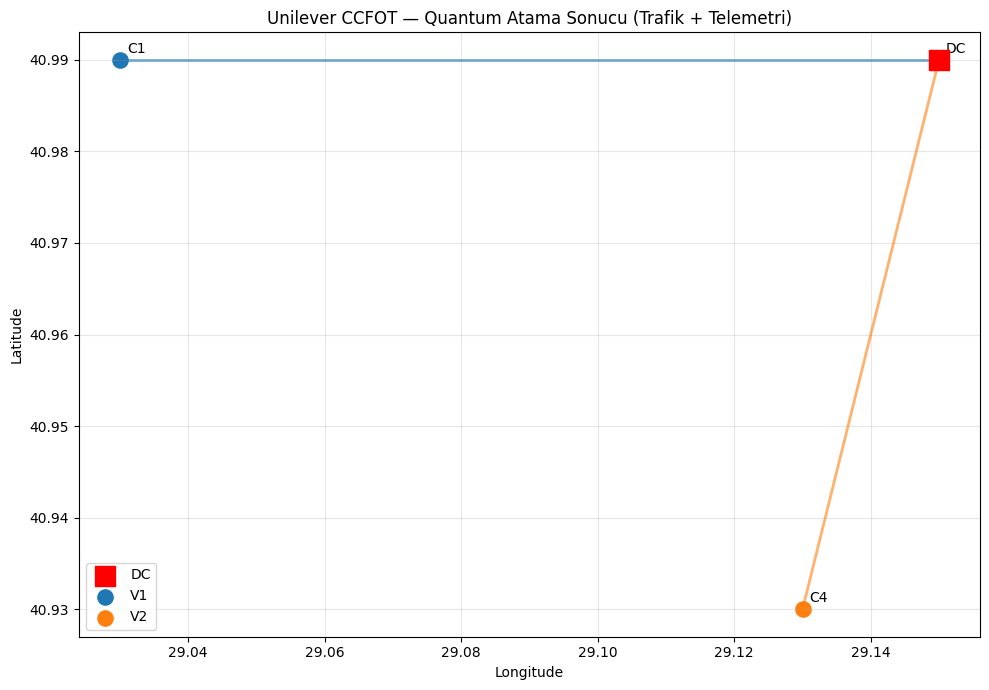

In [ ]:
def plot_assignment(customers, DC_LOCATION, assignment, usable_vehicles):
    fig, ax = plt.subplots(figsize=(10, 7))

    # DC
    ax.scatter(DC_LOCATION["lon"], DC_LOCATION["lat"], c="red", s=200, marker="s", label="DC", zorder=5)
    ax.annotate("DC", (DC_LOCATION["lon"], DC_LOCATION["lat"]), textcoords="offset points", xytext=(5,5))

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for i, (vid, custs) in enumerate(assignment.items()):
        if not custs:
            continue
        color = colors[i % len(colors)]
        for cid in custs:
            crow = customers[customers["id"] == cid].iloc[0]
            ax.scatter(crow["lon"], crow["lat"], c=color, s=120, label=f"{vid}" if cid == custs[0] else "")
            ax.annotate(cid, (crow["lon"], crow["lat"]), textcoords="offset points", xytext=(5,5))
            # çizgi DC → müşteri
            ax.plot([DC_LOCATION["lon"], crow["lon"]], [DC_LOCATION["lat"], crow["lat"]],
                    c=color, alpha=0.6, linewidth=2)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Unilever CCFOT — Quantum Atama Sonucu (Trafik + Telemetri)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_assignment(customers, DC_LOCATION, assignment, usable_vehicles)

## 8. Uçtan Uca Mimari Özeti

```
[Araç Telemetrisi IoT] ──┐
                         ├──► Veri Katmanı (sıcaklık, konum, yakıt)
[Google Traffic API]  ───┘
                              │
                              ▼
                    Maliyet / Risk Matrisi
                              │
                              ▼
                    QUBO Formülasyonu (CCFOT odaklı)
                              │
              ┌───────────────┼───────────────┐
              ▼               ▼               ▼
     StatevectorSampler   AerSampler    IBM Quantum
     (Ideal)              (Shot)        (Hardware)
              │               │               │
              └───────────────┼───────────────┘
                              ▼
                    En iyi atama + rota
                              │
                              ▼
                    CCFOT skoru + Operasyonel karar
```

### Gerçek Üretim İçin Öneriler
- Pairing/Column Generation ile büyük ölçek
- Hybrid: Quantum QUBO + klasik repair (time-window, gerçek rota)
- Streaming telemetry → periyodik re-optimizasyon
- Google Routes API (yeni) + traffic_model=pessimistic soğuk zincir için

## 9. Öğrenci / Operasyon Alıştırmaları

1. **Google API key** ekleyip `use_google=True` yapın → gerçek trafik sürelerini alın.
2. V3’ü (sıcaklık uyarılı) zorla kullanılabilir yapıp CCFOT skorunun nasıl düştüğünü görün.
3. `reps=1` vs `reps=3` karşılaştırın.
4. Yeni bir müşteri (C5) ekleyip modeli yeniden çözün.
5. IBM Quantum token ile `USE_IBM=True` yaparak gerçek donanıma gönderin (küçük instance).
6. Telemetriye “kapı açık süresi” ekleyip risk fonksiyonunu genişletin.

## 10. Kaynaklar

- Unilever CCFOT & Supply Chain: unilever.com (Mannheim DC %99.8 CCFOT)
- Google Maps Platform – Directions API (traffic_model)
- Qiskit Optimization & QAOA tutorials
- Vehicle Routing Problem QUBO formülasyonları (Lucas, Glover vb.)
- Unilever Ice Cream cold chain AI initiatives (2025)

---
**Hazırlayan notu:** Bu notebook Unilever CCFOT operasyonu için quantum computing’in nasıl entegre edilebileceğini gösteren uçtan uca bir eğitim/demo çalışmasıdır.  
Gerçek ölçekte production-ready sistem hybrid mimari + enterprise veri platformu gerektirir.

Başarılar! 🚀